<a href="https://colab.research.google.com/github/romanrudniev/MachineLearning/blob/main/%D0%92%D1%81%D1%83%D0%BF_%D0%B4%D0%BE_NLP(%D0%9A%D0%BB%D0%B0%D1%81%D0%B8%D1%84%D1%96%D0%BA%D0%B0%D1%86%D1%96%D1%8F_%D0%B2%D1%96%D0%B4%D0%B3%D1%83%D0%BA%D1%96%D0%B2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Вступ до NLP

In [83]:
!pip install nltk

In [84]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('movie_reviews')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


True

In [85]:
from nltk.corpus.reader import documents
from nltk.corpus import movie_reviews
import random

documents = [(list(movie_reviews.words(fileid)),category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

random.shuffle(documents)

print(documents[10])

(['"', 'shagadellic', '!', '"', ',', '"', 'groovy', ',', 'baby', '!', '"', '"', 'smashing', '!', '"', 'adorn', 'the', '1', '/', '4', 'page', 'ad', 'for', 'this', 'movie', 'tabbed', 'as', '"', 'the', '#', '1', 'comedy', 'in', 'america', '"', 'as', 'of', 'may', '8th', '.', 'did', 'we', 'attend', 'the', 'same', 'movie', '?', '!', 'at', '87', 'minutes', 'it', 'seemed', 'overlong', ',', 'like', 'a', 'snl', 'skit', 'on', 'steroids', ',', 'and', 'at', 'any', 'length', 'it', 'seemed', 'unfunny', '.', 'yes', ',', 'the', 'sets', 'and', 'costumes', 'were', 'an', 'interesting', 'exaggeration', 'of', '60s', 'pop', 'frills', ',', 'and', 'yes', ',', 'the', 'concept', ',', 'dealing', 'with', 'a', '60s', 'secret', 'agent', '/', 'pop', 'icon', '(', 'played', 'by', 'myers', ')', 'awakened', 'from', 'his', 'cryogenic', 'slumber', 'to', 'battle', 'his', 'arch', 'enemy', '(', 'dr', '.', 'evil', ',', 'also', 'played', 'by', 'myers', ')', 'in', 'the', 'present', 'day', ',', 'had', 'a', 'great', 'deal', 'of', 

In [86]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

def clear_words(words: list) -> list:
  return [ps.stem(w.lower()) for w in words if w.isalpha() and w.lower() not in stop_words]

In [87]:
print(stop_words)

{'weren', 'do', 'have', "shan't", 'both', 'being', 'and', 'what', 'through', 'she', 'too', 'aren', 'most', "you'd", 'against', 'ourselves', "don't", 'until', "couldn't", 'wasn', 's', 'doing', 'were', 'below', 'just', "she'll", 'all', 'further', 'because', 'above', 'hadn', "he's", 'we', 'doesn', 'of', 'didn', 'now', 'there', "he'd", "aren't", "he'll", 'on', 'did', 'whom', 'into', 'such', "that'll", 'our', "we'll", 'her', 'mustn', "doesn't", 'll', "isn't", 'when', 'your', "haven't", 'ours', 'o', 'own', 'its', 'ma', 'other', 'so', 'during', 'that', 'has', 'in', 'having', 'any', 'does', "it'll", 'himself', 'they', 'd', 'him', 'shouldn', 'theirs', "hadn't", 'can', "i've", 'yourselves', 'mightn', 'if', 'had', 'i', 'after', "weren't", 'these', 'this', 'is', 'it', "i'd", "they've", 'more', 'needn', 'down', 'me', 'here', 'his', "she's", 'how', 'by', 'or', 'over', 'are', 'who', 'up', 'will', 'about', 'where', 'them', 'from', 'before', "it'd", 'my', 'hasn', 're', "should've", "i'll", 'yours', "we

In [88]:
cleaned_document = [(" ".join(clear_words(doc)), label) for doc, label in documents]

In [89]:
print(cleaned_document[10])

('shagadel groovi babi smash adorn page ad movi tab comedi america may attend movi minut seem overlong like snl skit steroid length seem unfunni ye set costum interest exagger pop frill ye concept deal secret agent pop icon play myer awaken cryogen slumber battl arch enemi dr evil also play myer present day great deal potenti fun costum sceneri potenti movi make let throw hefti dose bathroom humor get wrong like good bubbl bathtub joke much next person type humor funniest thing movi wast yuor talent money way thing work day movi busi film call funniest peopl believ give film star set costum sadli unmet potenti', 'neg')


In [90]:
df = pd.DataFrame(cleaned_document, columns=['reviev', 'label'])
df.head(10)

,reviev,label
0,respect rush hour ultim exercis clich filmmak ...,pos
1,insid look scandal ridden run democrat preside...,pos
2,david spade snide sarcast sens humor work perf...,neg
3,capsul lesbian examin hush reverenti tone rese...,neg
4,spoil rich kid kelley mors chri klein receiv n...,neg
5,go movi much unfortun end see certain movi tra...,pos
6,folk disney common decenc resurrect yet anoth ...,neg
7,film tout explor relationship black sexual tro...,neg
8,like good action film metro action keep involv...,neg
9,endur shackleton legendari antarct expedit gre...,pos


<Axes: title={'center': 'Rozpodil Vidgykiv'}, xlabel='label'>

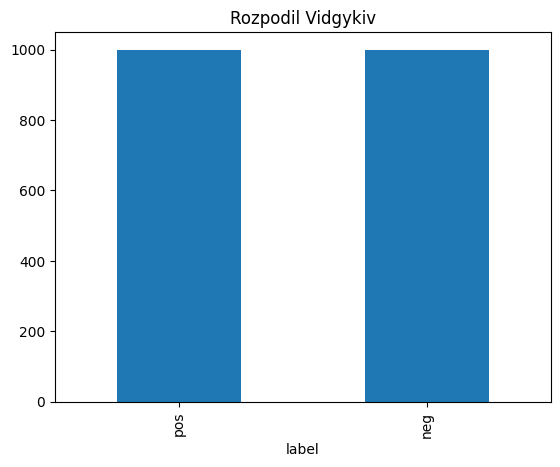

In [91]:
df['label'].value_counts().plot(kind='bar', title= 'Rozpodil Vidgykiv')

In [92]:
from numpy import vectorize
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['reviev'])
y = df['label']

In [93]:
print(X)
print(y)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 501022 stored elements and shape (2000, 25258)>
  Coords	Values
  (0, 18331)	2
  (0, 18899)	4
  (0, 10320)	5
  (0, 23122)	1
  (0, 7209)	1
  (0, 3931)	1
  (0, 7724)	1
  (0, 9960)	3
  (0, 18222)	1
  (0, 4499)	3
  (0, 17115)	1
  (0, 24871)	1
  (0, 505)	1
  (0, 17616)	1
  (0, 3141)	1
  (0, 20585)	1
  (0, 3287)	3
  (0, 8692)	2
  (0, 22895)	1
  (0, 3672)	2
  (0, 16358)	2
  (0, 20593)	1
  (0, 11181)	1
  (0, 4787)	1
  (0, 6652)	3
  :	:
  (1999, 18385)	1
  (1999, 9103)	1
  (1999, 16728)	1
  (1999, 3518)	1
  (1999, 22772)	1
  (1999, 1244)	1
  (1999, 5867)	1
  (1999, 22219)	1
  (1999, 21326)	1
  (1999, 9186)	2
  (1999, 4516)	1
  (1999, 16125)	3
  (1999, 23838)	1
  (1999, 16132)	2
  (1999, 23067)	1
  (1999, 4646)	1
  (1999, 1058)	2
  (1999, 11056)	1
  (1999, 1890)	1
  (1999, 2883)	1
  (1999, 20890)	1
  (1999, 11635)	3
  (1999, 12531)	1
  (1999, 20328)	1
  (1999, 11962)	1
0       pos
1       pos
2       neg
3       neg
4       neg
       .

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
model = LogisticRegression(max_iter=1000)
# model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [95]:
from sklearn.metrics import accuracy_score, confusion_matrix
print('Accurancy:', accuracy_score(y_test, y_pred))

Accurancy: 0.805


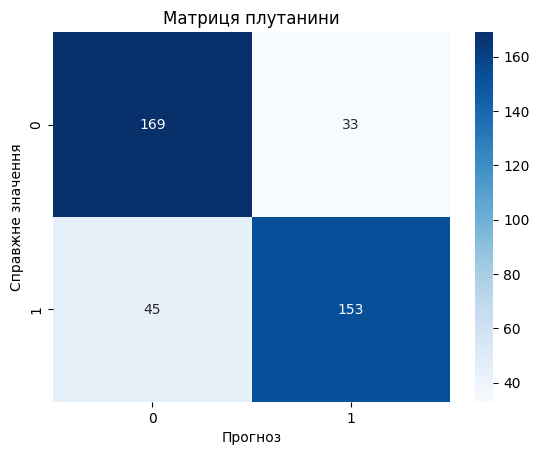

In [96]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Прогноз')
plt.ylabel('Справжне значення')
plt.title('Матриця плутанини')
plt.show()

In [97]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [98]:
def predict_review(text: str) -> str:
  cleaned = ' '.join(clear_words(word_tokenize(text)))
  vec = vectorizer.transform([cleaned])
  return model.predict(vec)[0]

In [99]:
type(predict_review('text'))

str

In [100]:
print(predict_review('The movie was boring'))
print(predict_review('Funny story! Thank'))
print(predict_review('hgjgjhjhjgjg'))
print(predict_review('The movie was boring and very good'))
print(predict_review('I really liked this cartoon. It was funny, colorful, and the characters were amazing.'))
print(predict_review('This movie was amazing! The story was interesting and the actors were great.'))
print(predict_review('Bad movie'))
print(predict_review('Best movie'))
print(predict_review('Good movie'))
print(predict_review('This movie was boring and too long. The story was not interesting.'))
print(predict_review('I"m sad that the movie is over.'))

neg
neg
neg
neg
neg
neg
neg
neg
neg
neg
neg


| review                | Naive Bayes  | Logistic Regression |Actual|
|-----------------------|--------------------|-----------------------------|--|
| 'The movie was boring' | neg                | neg                         |neg |
| 'Funny story! Thanks'  | pos                | neg                         | pos|
| 'hgjgjhjhjgjg'|pos |neg |? |
| 'The movie was boring and wery good'|neg |neg |? |
|I really liked this cartoon. It was funny, colorful, and the characters were amazing. | pos| neg|pos |
|This movie was amazing! The story was interesting and the actors were great |pos |neg |pos |
|Bad movie |neg |neg |neg |
|Best movie |pos |neg |pos |
|Good movie |neg |neg |pos |
|This movie was boring and too long. The story was not interesting. |neg |neg |neg |
|I"m sad that the movie is over.|neg |neg |pos |